Notebook for analyzing the relationship between market data and extracted topics.

In [ ]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

from wordcloud import WordCloud

sys.path.append("../")

In [4]:
df = pd.read_pickle("../data/preprocessed/df_preprocessed_CB_corpus_with_topics.pkl")

[*********************100%***********************]  3 of 3 completed


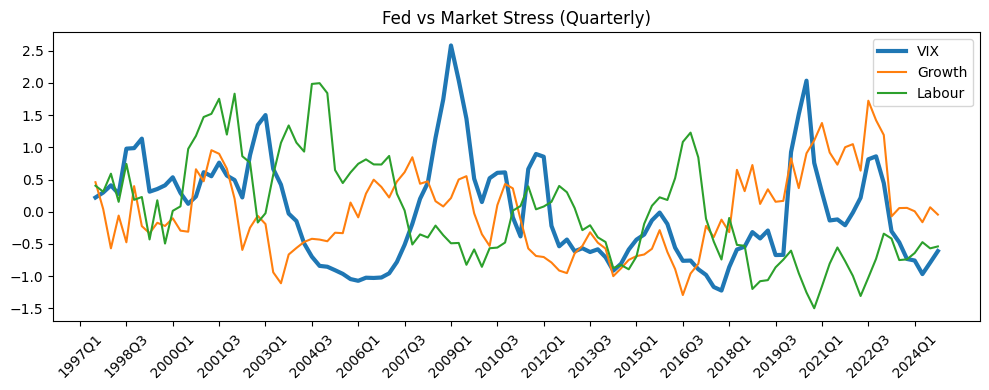

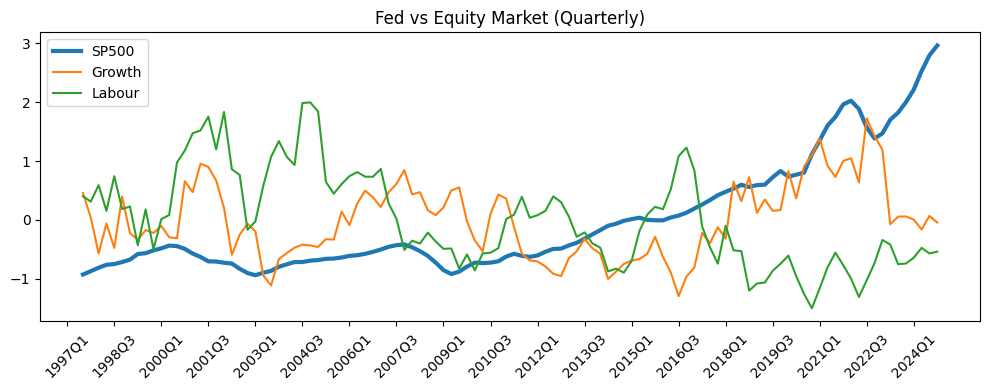

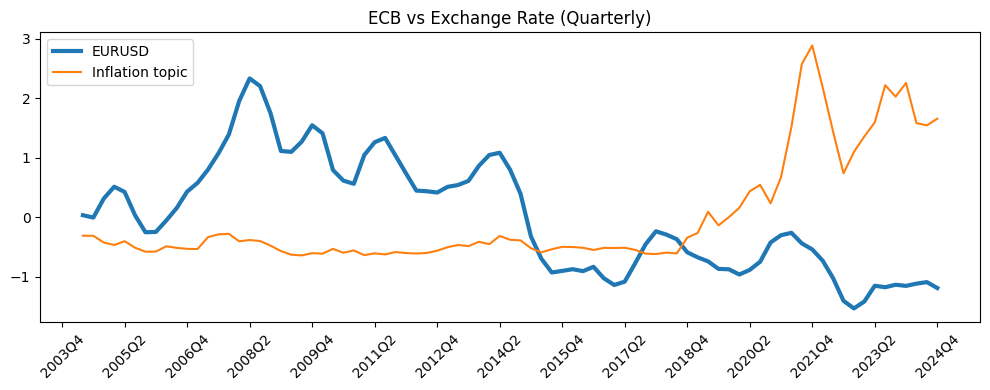

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df["quarter"] = df["date"].dt.to_period("Q")

tickers = ["^VIX", "^GSPC", "EURUSD=X"]
data = yf.download(tickers, start="1997-01-01", end="2025-01-01")["Close"]

data = data.resample("QE").last()
data = data.reset_index()
data["quarter"] = data["Date"].dt.to_period("Q")

df_fed = df[df["bank"].str.contains("federal reserve", case=False, na=False)].copy()

fed_q = df_fed.groupby("quarter").agg(
    Growth=("topic_13", "mean"),
    Labour=("topic_12", "mean"),
    Households=("topic_11", "mean")
).reset_index()

fed_merge = pd.merge(fed_q, data, on="quarter", how="inner").set_index("quarter")

df_ecb = df[df["bank"].str.contains("european central bank", case=False, na=False)].copy()

ecb_q = df_ecb.groupby("quarter").agg(
    Inflation=("topic_7", "mean")
).reset_index()

ecb_merge = pd.merge(ecb_q, data, on="quarter", how="inner").set_index("quarter")

def normalize_and_smooth(df_in, cols, window=3):
    df_plot = df_in[cols].dropna()
    df_norm = (df_plot - df_plot.mean()) / df_plot.std()
    df_norm = df_norm.rolling(window).mean()
    df_norm.index = df_norm.index.astype(str)
    return df_norm

fed_vix = normalize_and_smooth(fed_merge, ["^VIX","Growth","Labour","Households"])

plt.figure(figsize=(10,4))
plt.plot(fed_vix.index, fed_vix["^VIX"], label="VIX", linewidth=3)
plt.plot(fed_vix.index, fed_vix["Growth"], label="Growth")
plt.plot(fed_vix.index, fed_vix["Labour"], label="Labour")
plt.legend()
plt.title("Fed vs Market Stress (Quarterly)")
plt.xticks(fed_vix.index[::6], rotation=45)
plt.tight_layout()
plt.show()

fed_sp = normalize_and_smooth(fed_merge, ["^GSPC","Growth","Labour"])

plt.figure(figsize=(10,4))
plt.plot(fed_sp.index, fed_sp["^GSPC"], label="SP500", linewidth=3)
plt.plot(fed_sp.index, fed_sp["Growth"], label="Growth")
plt.plot(fed_sp.index, fed_sp["Labour"], label="Labour")
plt.legend()
plt.title("Fed vs Equity Market (Quarterly)")
plt.xticks(fed_sp.index[::6], rotation=45)
plt.tight_layout()
plt.show()

ecb_fx = normalize_and_smooth(ecb_merge, ["EURUSD=X","Inflation"])

plt.figure(figsize=(10,4))
plt.plot(ecb_fx.index, ecb_fx["EURUSD=X"], label="EURUSD", linewidth=3)
plt.plot(ecb_fx.index, ecb_fx["Inflation"], label="Inflation topic")
plt.legend()
plt.title("ECB vs Exchange Rate (Quarterly)")
plt.xticks(ecb_fx.index[::6], rotation=45)
plt.tight_layout()
plt.show()

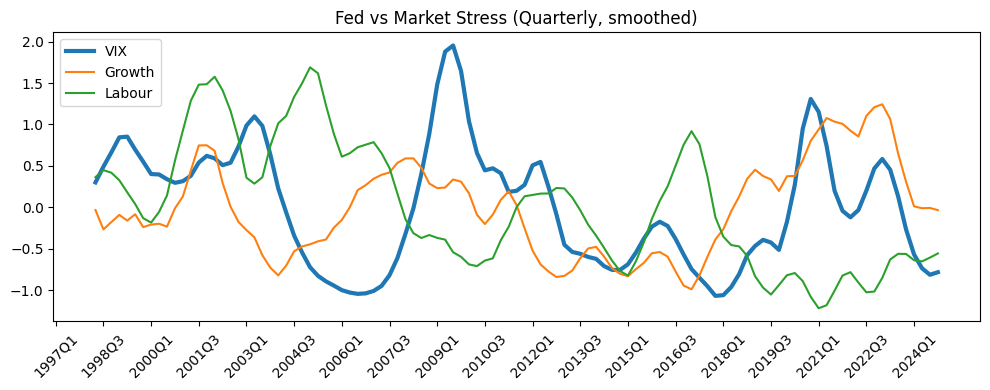

In [ ]:
# fed_vix from prev cell

fed_vix_plot = fed_vix.copy()

fed_vix_plot = fed_vix_plot.rolling(4).mean()

plt.figure(figsize=(10,4))
plt.plot(fed_vix_plot.index, fed_vix_plot["^VIX"], label="VIX", linewidth=3)
plt.plot(fed_vix_plot.index, fed_vix_plot["Growth"], label="Growth")
plt.plot(fed_vix_plot.index, fed_vix_plot["Labour"], label="Labour")
plt.xticks(fed_vix_plot.index[::6], rotation=45)
plt.legend()
plt.title("Fed vs Market Stress (Quarterly, smoothed)")
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


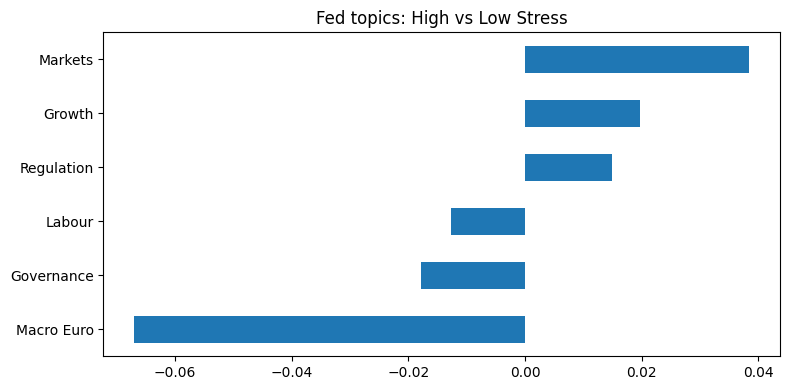


Top differences (High VIX - Low VIX):

Macro Euro   -0.066974
Governance   -0.017910
Labour       -0.012611
Regulation    0.014910
Growth        0.019634
Markets       0.038425
dtype: float64


In [33]:
df_fed = df[df["bank"].str.contains("federal reserve", case=False, na=False)].copy()
df_fed["date"] = pd.to_datetime(df_fed["date"])
df_fed["quarter"] = df_fed["date"].dt.to_period("Q")

topic_cols = [c for c in df.columns if c.startswith("topic_")]

fed_q = df_fed.groupby("quarter")[topic_cols].mean().reset_index()

vix = yf.download("^VIX", start="1997-01-01", end="2025-01-01")

if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.get_level_values(0)

vix = vix.reset_index()
vix = vix[["Date", "Close"]]
vix.columns = ["Date", "VIX"]

vix = vix.set_index("Date").resample("QE").mean().reset_index()
vix["quarter"] = vix["Date"].dt.to_period("Q")

fed_merge = pd.merge(
    fed_q,
    vix[["quarter", "VIX"]],
    on="quarter",
    how="inner"
).set_index("quarter")

high = fed_merge[fed_merge["VIX"] >= fed_merge["VIX"].quantile(0.8)]
low  = fed_merge[fed_merge["VIX"] <= fed_merge["VIX"].quantile(0.2)]

diff = (high[topic_cols].mean() - low[topic_cols].mean()).sort_values()

topic_labels = {
    "topic_0": "Regulation",
    "topic_1": "EU integration",
    "topic_2": "Governance",
    "topic_3": "Markets",
    "topic_4": "Liquidity",
    "topic_5": "Islamic finance",
    "topic_6": "Macro Euro",
    "topic_7": "Inflation",
    "topic_8": "Climate",
    "topic_9": "Macroprudential",
    "topic_10": "Trade",
    "topic_11": "Households",
    "topic_12": "Labour",
    "topic_13": "Growth",
    "topic_14": "Payments",
    "topic_15": "Fintech",
    "topic_16": "FX"
}

top = pd.concat([diff.head(3), diff.tail(3)])
top.index = top.index.map(topic_labels)
plt.figure(figsize=(8,4))
top.plot(kind="barh")
plt.title("Fed topics: High vs Low Stress")
plt.tight_layout()
plt.show()
print("\nTop differences (High VIX - Low VIX):\n")
print(top)

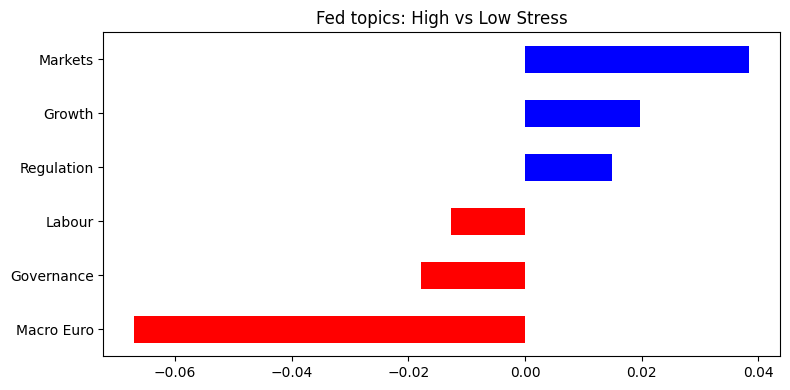


Top differences (High VIX - Low VIX):

Macro Euro   -0.066974
Governance   -0.017910
Labour       -0.012611
Regulation    0.014910
Growth        0.019634
Markets       0.038425
dtype: float64


In [34]:
top = pd.concat([diff.head(3), diff.tail(3)])
top.index = top.index.map(topic_labels)

colors = ["red" if v < 0 else "blue" for v in top.values]

plt.figure(figsize=(8,4))
top.plot(kind="barh", color=colors)
plt.title("Fed topics: High vs Low Stress")
plt.tight_layout()
plt.show()

print("\nTop differences (High VIX - Low VIX):\n")
print(top)